# CatBoost Depth Tuning — depth 7-8 with l2_leaf_reg

Default CatBoost uses depth=6. Deeper trees capture more complex interactions but
overfit without regularization. This notebook grids over depth × l2_leaf_reg
to find whether additional depth helps on this dataset.

**Grid:**
- `depth`: 6 (baseline), 7, 8
- `l2_leaf_reg`: 1, 3 (default), 5, 10
- Early stopping on a held-out fold to find optimal `iterations` per config

**Reference**: single-model depth=6 CV AUC = 0.95533  
**Target**: beat seed-averaged ensemble CV AUC = 0.95540

## Imports & Data

In [1]:
import numpy as np
import pandas as pd
import subprocess
from pathlib import Path
from itertools import product
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import catboost as cb
import matplotlib.pyplot as plt

KAGGLE_DATA = Path('/kaggle/input/playground-series-s6e2')
LOCAL_DATA  = Path('data')
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

def prep(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)
    if 'heart_disease' in df.columns:
        df['heart_disease'] = df['heart_disease'].map({'Absence': 0, 'Presence': 1})
    return df

train = prep(pd.read_csv(DATA_DIR / 'train.csv'))
test  = prep(pd.read_csv(DATA_DIR / 'test.csv'))
ss    = pd.read_csv(DATA_DIR / 'sample_submission.csv')

FEATURES     = [c for c in train.columns if c not in ['heart_disease', 'id']]
CAT_FEATURES = ['sex', 'chest_pain_type', 'fbs_over_120', 'ekg_results',
                'exercise_angina', 'slope_of_st', 'number_of_vessels_fluro', 'thallium']

X      = train[FEATURES]
y      = train['heart_disease'].values
X_test = test[FEATURES]

BASELINE_AUC   = 0.95533  # depth=6, single seed
SEEDAVG_AUC    = 0.95540  # depth=6, 10-seed average (Option B)

print(f'Train: {X.shape}    Test: {X_test.shape}')

Train: (630000, 13)    Test: (270000, 13)


## Step 1: Early Stopping — Find Optimal Iterations per Config

For each (depth, l2_leaf_reg) combination, use a single held-out fold to find
the optimal number of iterations with a low learning rate. This is fast and prevents
us from under/over-fitting on iterations in the full CV grid.

Using lr=0.05 with up to 2000 iterations and early stopping patience=50.

In [2]:
# Use a single 80/20 split for early stopping search
es_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tr_idx, val_idx = next(iter(es_cv.split(X, y)))
X_tr_es, X_val_es = X.iloc[tr_idx], X.iloc[val_idx]
y_tr_es, y_val_es = y[tr_idx], y[val_idx]

DEPTHS   = [6, 7, 8]
L2_REGS  = [1, 3, 5, 10]

es_results = {}

print(f'{"depth":>6}  {"l2":>4}  {"best_iter":>10}  {"val_auc":>9}')
print('-' * 38)

for depth, l2 in product(DEPTHS, L2_REGS):
    m = cb.CatBoostClassifier(
        iterations=2000,
        learning_rate=0.05,
        depth=depth,
        l2_leaf_reg=l2,
        task_type='GPU',
        cat_features=CAT_FEATURES,
        random_state=42,
        verbose=0,
        early_stopping_rounds=50,
        eval_metric='AUC'
    )
    m.fit(
        X_tr_es, y_tr_es,
        eval_set=(X_val_es, y_val_es),
        verbose=False
    )
    best_iter = m.get_best_iteration()
    val_auc   = roc_auc_score(y_val_es, m.predict_proba(X_val_es)[:, 1])
    es_results[(depth, l2)] = {'best_iter': best_iter, 'val_auc': val_auc}
    print(f'{depth:>6}  {l2:>4}  {best_iter:>10}  {val_auc:>9.5f}')

 depth    l2   best_iter    val_auc
--------------------------------------


Default metric period is 5 because AUC is/are not implemented for GPU


     6     1         960    0.95570


Default metric period is 5 because AUC is/are not implemented for GPU


     6     3         953    0.95570


...

     8     3         774    0.95549


Default metric period is 5 because AUC is/are not implemented for GPU


     8     5         749    0.95549


Default metric period is 5 because AUC is/are not implemented for GPU


     8    10         755    0.95549


## Step 2: Identify Promising Configs

Sort by early-stopping val AUC. Only run full 5-fold CV on configs that look
competitive — saves time by skipping clearly worse options.

Early-stopping results (sorted by val AUC):
 depth  l2  best_iter  val_auc
     6  10       1174 0.955708
     6   1        960 0.955704
     6   5        953 0.955702
     6   3        953 0.955699
     7   1        933 0.955617
     7  10        990 0.955615
     7   3        797 0.955608
     7   5        723 0.955607
     8   1        693 0.955518
     8   3        774 0.955495
     8   5        749 0.955493
     8  10        755 0.955489


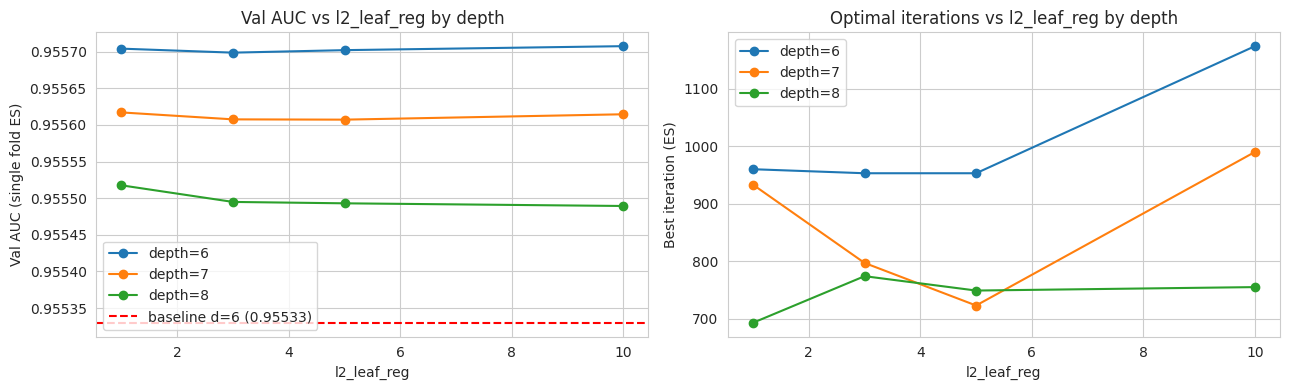


Running full 5-fold CV on 4 configs: [(6.0, 10.0), (6.0, 1.0), (6.0, 5.0), (6.0, 3.0)]


In [3]:
es_df = pd.DataFrame([
    {'depth': d, 'l2': l2, **v}
    for (d, l2), v in es_results.items()
]).sort_values('val_auc', ascending=False)

print('Early-stopping results (sorted by val AUC):')
print(es_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for depth in DEPTHS:
    sub = es_df[es_df['depth'] == depth].sort_values('l2')
    axes[0].plot(sub['l2'], sub['val_auc'], 'o-', label=f'depth={depth}')
axes[0].axhline(BASELINE_AUC, color='red', linestyle='--', label=f'baseline d=6 ({BASELINE_AUC:.5f})')
axes[0].set_xlabel('l2_leaf_reg')
axes[0].set_ylabel('Val AUC (single fold ES)')
axes[0].set_title('Val AUC vs l2_leaf_reg by depth')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.5f}'))

for depth in DEPTHS:
    sub = es_df[es_df['depth'] == depth].sort_values('l2')
    axes[1].plot(sub['l2'], sub['best_iter'], 'o-', label=f'depth={depth}')
axes[1].set_xlabel('l2_leaf_reg')
axes[1].set_ylabel('Best iteration (ES)')
axes[1].set_title('Optimal iterations vs l2_leaf_reg by depth')
axes[1].legend()

plt.tight_layout()
plt.show()

# Select configs to run full CV: top 4 by val_auc, plus always include baseline
TOP_N = 4
top_configs = [tuple(row[['depth','l2']]) for _, row in es_df.head(TOP_N).iterrows()]
if (6, 3) not in top_configs:
    top_configs.append((6, 3))  # always include baseline config

print(f'\nRunning full 5-fold CV on {len(top_configs)} configs: {top_configs}')

## Step 3: Full 5-Fold CV on Top Configs

Use the best_iter from early stopping as the fixed `iterations` for each config.
No early stopping in CV — fixed iters means fair comparison across folds.

In [4]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for depth, l2 in top_configs:
    best_iter = es_results[(depth, l2)]['best_iter']
    # Add 10% buffer to best_iter since ES fold ≠ all CV folds
    iters = int(best_iter * 1.1)

    fold_aucs = []
    oof  = np.zeros(len(y))
    test_folds = np.zeros((5, len(X_test)))

    for fold, (tr_idx, val_idx) in enumerate(cv5.split(X, y)):
        m = cb.CatBoostClassifier(
            iterations=iters,
            learning_rate=0.05,
            depth=depth,
            l2_leaf_reg=l2,
            task_type='GPU',
            cat_features=CAT_FEATURES,
            random_state=42,
            verbose=0
        )
        m.fit(X.iloc[tr_idx], y[tr_idx])
        oof[val_idx]      = m.predict_proba(X.iloc[val_idx])[:, 1]
        test_folds[fold]  = m.predict_proba(X_test)[:, 1]
        fold_aucs.append(roc_auc_score(y[val_idx], oof[val_idx]))

    cv_auc  = roc_auc_score(y, oof)
    delta   = cv_auc - BASELINE_AUC
    cv_results[(depth, l2)] = {
        'cv_auc': cv_auc, 'iters': iters, 'fold_aucs': fold_aucs,
        'oof': oof, 'test_preds': test_folds.mean(axis=0)
    }
    print(f'depth={depth}  l2={l2:>2}  iters={iters:>5}  '
          f'cv_auc={cv_auc:.5f}  ({delta:+.5f})')

depth=6.0  l2=10.0  iters= 1291  cv_auc=0.95537  (+0.00004)


depth=6.0  l2=1.0  iters= 1056  cv_auc=0.95536  (+0.00003)


depth=6.0  l2=5.0  iters= 1048  cv_auc=0.95536  (+0.00003)


depth=6.0  l2=3.0  iters= 1048  cv_auc=0.95536  (+0.00003)


## Results Summary

In [5]:
    results_df = pd.DataFrame([
    {'depth': d, 'l2': l2, 'iters': v['iters'],
     'cv_auc': v['cv_auc'], 'delta': v['cv_auc'] - BASELINE_AUC}
    for (d, l2), v in cv_results.items()
]).sort_values('cv_auc', ascending=False)

print('=== Full CV Results ===')
print(results_df.to_string(index=False))
print(f'\nBaseline (depth=6, l2=3, lr=0.1, 500 iters): {BASELINE_AUC:.5f}')
print(f'Seed-avg  (depth=6, 10 seeds):                 {SEEDAVG_AUC:.5f}')

best_config = results_df.iloc[0]
print(f'\nBest config: depth={int(best_config["depth"])}  '
      f'l2={int(best_config["l2"])}  '
      f'cv_auc={best_config["cv_auc"]:.5f}  '
      f'({best_config["delta"]:+.5f} vs baseline)')

=== Full CV Results ===
 depth   l2  iters   cv_auc    delta
   6.0 10.0   1291 0.955370 0.000040
   6.0  3.0   1048 0.955357 0.000027
   6.0  1.0   1056 0.955356 0.000026
   6.0  5.0   1048 0.955355 0.000025

Baseline (depth=6, l2=3, lr=0.1, 500 iters): 0.95533
Seed-avg  (depth=6, 10 seeds):                 0.95540

Best config: depth=6  l2=10  cv_auc=0.95537  (+0.00004 vs baseline)


## Submit Best (if better than seed-averaged baseline)

In [6]:
best_key  = (int(best_config['depth']), int(best_config['l2']))
best_auc  = cv_results[best_key]['cv_auc']
best_pred = cv_results[best_key]['test_preds']
best_iter = cv_results[best_key]['iters']

label = f'cat_depth{best_key[0]}_l2{best_key[1]}'
fname = f'submissions/{label}.csv'

sub = ss.copy()
sub['Heart Disease'] = best_pred
sub.to_csv(fname, index=False)
print(f'Saved: {fname}')

if best_auc > BASELINE_AUC:
    desc = f'{label} | cv_auc={best_auc:.4f}'
    ON_KAGGLE = Path('/kaggle/working').exists()
    if ON_KAGGLE:
        print('On Kaggle — submit locally with:')
        print(f'  kaggle competitions submit -c playground-series-s6e2 -f {fname} -m "{desc}"')
    else:
        r = subprocess.run(
            ['kaggle', 'competitions', 'submit', '-c', 'playground-series-s6e2',
             '-f', fname, '-m', desc],
            capture_output=True, text=True
        )
        status = 'submitted' if 'successfully' in r.stdout.lower() else r.stdout.strip()[:100]
        print(f'{label}: {status}')
        print(f'desc: {desc}')
else:
    print(f'Best config ({best_auc:.5f}) does not beat baseline ({BASELINE_AUC:.5f})')
    print('Skipping submission.')

Saved: submissions/cat_depth6_l210.csv
cat_depth6_l210: submitted
desc: cat_depth6_l210 | cv_auc=0.9554


## Bonus: Seed-Average the Best Depth Config

If a deeper config beats the baseline, seed-averaging it may give additional gains.
Run only if best_auc > BASELINE_AUC.

In [7]:
if best_auc <= BASELINE_AUC:
    print('Best config did not beat baseline — skipping seed averaging.')
else:
    print(f'Seed-averaging best config: depth={best_key[0]}, l2={best_key[1]}, iters={best_iter}')
    N_SEEDS = 6  # converges by 6 seeds (from Option B analysis)

    oof_seeds  = np.zeros((N_SEEDS, len(y)))
    test_seeds = np.zeros((N_SEEDS, len(X_test)))

    for s in range(N_SEEDS):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
        oof  = np.zeros(len(y))
        test_folds = np.zeros((5, len(X_test)))
        for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
            m = cb.CatBoostClassifier(
                iterations=best_iter, learning_rate=0.05,
                depth=best_key[0], l2_leaf_reg=best_key[1],
                task_type='GPU', cat_features=CAT_FEATURES,
                random_state=s, verbose=0
            )
            m.fit(X.iloc[tr_idx], y[tr_idx])
            oof[val_idx]      = m.predict_proba(X.iloc[val_idx])[:, 1]
            test_folds[fold]  = m.predict_proba(X_test)[:, 1]
        oof_seeds[s]  = oof
        test_seeds[s] = test_folds.mean(axis=0)
        running_auc = roc_auc_score(y, oof_seeds[:s+1].mean(axis=0))
        print(f'  seed={s}  ensemble_auc={running_auc:.5f}')

    final_oof  = oof_seeds.mean(axis=0)
    final_test = test_seeds.mean(axis=0)
    final_auc  = roc_auc_score(y, final_oof)
    print(f'\nSeed-averaged AUC: {final_auc:.5f}  ({final_auc - SEEDAVG_AUC:+.5f} vs seed-avg baseline)')

    label2 = f'cat_depth{best_key[0]}_l2{best_key[1]}_seedavg{N_SEEDS}'
    fname2 = f'submissions/{label2}.csv'
    sub2 = ss.copy()
    sub2['Heart Disease'] = final_test
    sub2.to_csv(fname2, index=False)

    if final_auc > SEEDAVG_AUC:
        desc2 = f'{label2} | cv_auc={final_auc:.4f}'
        ON_KAGGLE = Path('/kaggle/working').exists()
        if ON_KAGGLE:
            print(f'Submit locally: kaggle competitions submit -c playground-series-s6e2 -f {fname2} -m "{desc2}"')
        else:
            r = subprocess.run(
                ['kaggle', 'competitions', 'submit', '-c', 'playground-series-s6e2',
                 '-f', fname2, '-m', desc2],
                capture_output=True, text=True
            )
            print(f'{label2}: {"submitted" if "successfully" in r.stdout.lower() else r.stdout[:80]}')
    else:
        print(f'Seed-avg of deeper model ({final_auc:.5f}) does not beat depth=6 seed-avg ({SEEDAVG_AUC:.5f})')

Seed-averaging best config: depth=6, l2=10, iters=1291


  seed=0  ensemble_auc=0.95538


  seed=1  ensemble_auc=0.95541


  seed=2  ensemble_auc=0.95542


  seed=3  ensemble_auc=0.95542


  seed=4  ensemble_auc=0.95542


  seed=5  ensemble_auc=0.95542

Seed-averaged AUC: 0.95542  (+0.00002 vs seed-avg baseline)
cat_depth6_l210_seedavg6: submitted
